# KF7029 — Image Anomaly Detection: K-Pipelines Corrosion Dataset (Augmented)
**Student:** Sibtain Mehdi Razvi Syed | **ID:** W25039720

## Overview
This notebook implements and evaluates anomaly detection models on the K-Pipelines Augmented dataset — a publicly available image dataset of corroded and non-corroded oil and gas pipeline surfaces.

**Why Augmented split?** The Standard split provides only 60 test images which is insufficient for reliable evaluation in a dissertation. The Augmented split provides 108 test images with perfect class balance (54 corrosion, 54 no_corrosion), enabling more reliable statistical analysis.

**Dataset summary:**
- Train: 864 images (434 normal, 430 corrosion) — only normal used for training
- Validation: 108 images (54 normal, 54 corrosion)
- Test: 108 images (54 normal, 54 corrosion)

**Models evaluated:**
- Deep learning: Convolutional Autoencoder
- Classical baselines on encoder features: Isolation Forest, One-Class SVM

**Reference:** Ramos, Casas & Rivas-Echeverría (2025). Intelligent Systems with Applications, Elsevier.

## 1. Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              f1_score, precision_score, recall_score)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('All libraries imported successfully')
print('Device:', device)

All libraries imported successfully
Device: cpu


## 2. Dataset Paths — Augmented Split

In [2]:
BASE_PATH  = r'C:\Users\Administrator\Documents\kf7029-w25039720\datasets\k-pipelines\K-Pipelines-main\K-Pipelines-main\Augmented'
TRAIN_PATH = os.path.join(BASE_PATH, 'train')
VALID_PATH = os.path.join(BASE_PATH, 'valid')
TEST_PATH  = os.path.join(BASE_PATH, 'test')

print('Train path exists:', os.path.exists(TRAIN_PATH))
print('Valid path exists:', os.path.exists(VALID_PATH))
print('Test path exists: ', os.path.exists(TEST_PATH))

Train path exists: True
Valid path exists: True
Test path exists:  True


## 3. Exploratory Data Analysis
Understanding the Augmented dataset structure before modelling. The Augmented split has balanced classes and larger splits than Standard, making it more suitable for dissertation-level evaluation.

Image counts per split (Augmented):
  Train Corrosion: 430
  Train No Corrosion: 434
  Valid Corrosion: 54
  Valid No Corrosion: 54
  Test Corrosion: 54
  Test No Corrosion: 54


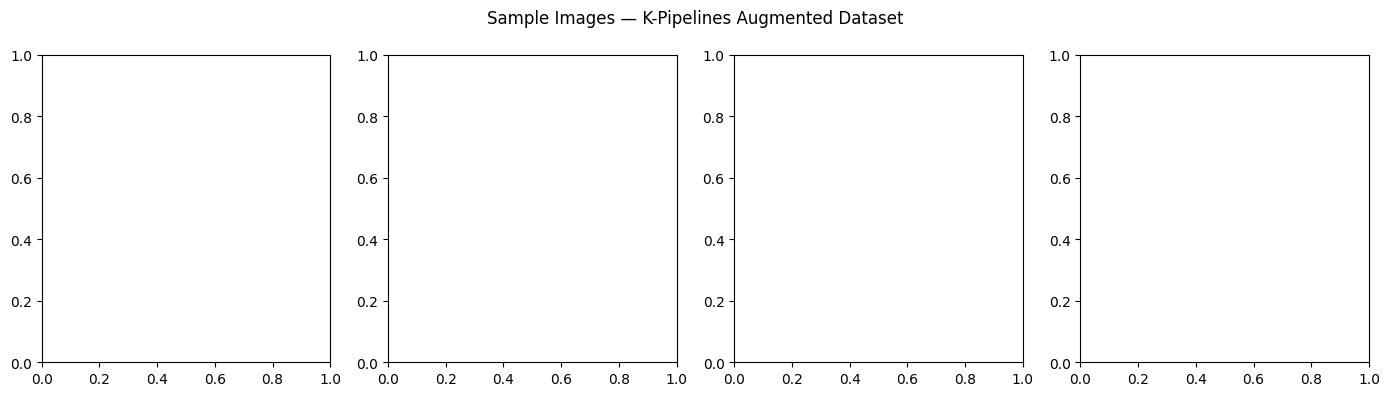

In [3]:
from pathlib import Path

splits = {
    'Train Corrosion':    Path(TRAIN_PATH) / 'corrosion',
    'Train No Corrosion': Path(TRAIN_PATH) / 'no_corrosion',
    'Valid Corrosion':    Path(VALID_PATH) / 'corrosion',
    'Valid No Corrosion': Path(VALID_PATH) / 'no_corrosion',
    'Test Corrosion':     Path(TEST_PATH)  / 'corrosion',
    'Test No Corrosion':  Path(TEST_PATH)  / 'no_corrosion',
}

print('Image counts per split (Augmented):')
for name, path in splits.items():
    count = len(list(path.glob('*.png')) + list(path.glob('*.jpg')))
    print(f'  {name}: {count}')

# Show sample images
from PIL import Image
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
normal_imgs    = list((Path(TRAIN_PATH) / 'no_corrosion').glob('*.png'))[:2]
corrosion_imgs = list((Path(TRAIN_PATH) / 'corrosion').glob('*.png'))[:2]
sample_imgs    = normal_imgs + corrosion_imgs
titles         = ['Normal', 'Normal', 'Corrosion', 'Corrosion']

for ax, img_path, title in zip(axes, sample_imgs, titles):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(title, color='green' if 'Normal' in title else 'red')
    ax.axis('off')

plt.suptitle('Sample Images — K-Pipelines Augmented Dataset')
plt.tight_layout()
plt.savefig(r'C:\Users\Administrator\Documents\kf7029-w25039720\results\figures\kpipelines_aug_samples.png', dpi=150)
plt.show()

## 4. Data Loading
Images resized to 128x128. Training uses only normal (no_corrosion) images — 434 images. Validation and test sets contain both classes.

In [4]:
IMAGE_SIZE = 128
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset = ImageFolder(TRAIN_PATH, transform=transform)
valid_dataset = ImageFolder(VALID_PATH, transform=transform)
test_dataset  = ImageFolder(TEST_PATH,  transform=transform)

print('Classes:', train_dataset.classes)
print('Class to index:', train_dataset.class_to_idx)
print(f'Train: {len(train_dataset)} | Valid: {len(valid_dataset)} | Test: {len(test_dataset)}')

# Extract normal images only for training
normal_class   = train_dataset.class_to_idx['no_corrosion']
normal_indices = [i for i, (_, label) in enumerate(train_dataset.samples)
                  if label == normal_class]
train_normal   = Subset(train_dataset, normal_indices)

train_loader = DataLoader(train_normal,  batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# Get corrosion class index for label remapping
corrosion_cls = test_dataset.class_to_idx['corrosion']

print(f'\nNormal training images: {len(train_normal)}')
print(f'Test batches: {len(test_loader)}')

Classes: ['corrosion', 'no_corrosion']
Class to index: {'corrosion': 0, 'no_corrosion': 1}
Train: 864 | Valid: 108 | Test: 108

Normal training images: 434
Test batches: 4


## 5. Convolutional Autoencoder (Architecture)
The Convolutional Autoencoder learns to compress and reconstruct normal pipeline images. Trained exclusively on normal images. At inference, corroded images are expected to produce higher reconstruction error.

Architecture: Encoder (3 conv layers, 32→64→128 filters) → Decoder (3 transposed conv layers). No batch normalisation to avoid feature collapse.

In [5]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder: 128x128 -> 16x16
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),   nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        # Decoder: 16x16 -> 128x128
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 2, stride=2),  nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 2, stride=2),   nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def encode(self, x):
        """Extract encoder features for classical baseline comparison."""
        return self.encoder(x)

model = ConvAutoencoder().to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): ConvTranspose2d(32, 3, kernel_size=(2, 2), stride=(2, 2))
    (5): Sigmoid()
  )
)

Total parameters: 134,691


## 6. Convolutional Autoencoder (Training)
Adam optimiser, learning rate 1e-3, MSE loss. Trained for 50 epochs on normal images only.

Epoch [10/50]  Loss: 0.016492
Epoch [20/50]  Loss: 0.010891
Epoch [30/50]  Loss: 0.009600
Epoch [40/50]  Loss: 0.008594
Epoch [50/50]  Loss: 0.007970


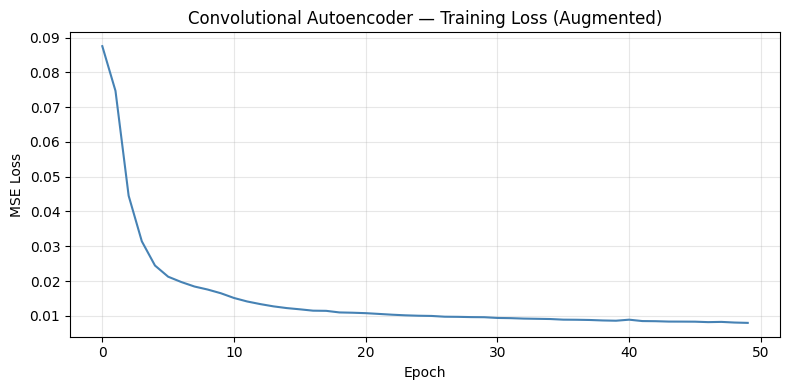

In [6]:
criterion    = nn.MSELoss()
optimizer    = torch.optim.Adam(model.parameters(), lr=1e-3)
NUM_EPOCHS   = 50
train_losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), images)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}]  Loss: {avg_loss:.6f}')

plt.figure(figsize=(8, 4))
plt.plot(train_losses, color='steelblue')
plt.title('Convolutional Autoencoder — Training Loss (Augmented)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\Administrator\Documents\kf7029-w25039720\results\figures\conv_ae_aug_training_loss.png', dpi=150)
plt.show()

## 7. Convolutional Autoencoder (Evaluation)
Anomaly score = mean pixel-wise squared reconstruction error. Threshold set at 50th percentile matching the balanced test set (50% anomaly ratio).

In [7]:
results = {}

def evaluate_model(name, scores, preds, y_true):
    results[name] = {
        'ROC-AUC':   round(roc_auc_score(y_true, scores), 4),
        'PR-AUC':    round(average_precision_score(y_true, scores), 4),
        'F1':        round(f1_score(y_true, preds), 4),
        'Precision': round(precision_score(y_true, preds), 4),
        'Recall':    round(recall_score(y_true, preds), 4)
    }
    print(f'\n=== {name} ===')
    for metric, value in results[name].items():
        print(f'  {metric}: {value}')

model.eval()
ae_errors   = []
true_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images)
        errors  = torch.mean(torch.pow(images - outputs, 2), dim=[1, 2, 3]).cpu().numpy()
        ae_errors.extend(errors)
        true_labels.extend(labels.numpy())

ae_errors   = np.array(ae_errors)
true_labels = np.array(true_labels)

# Remap: corrosion=1 (anomalous), no_corrosion=0 (normal)
true_labels_remapped = (true_labels == corrosion_cls).astype(int)

print(f'Test images: {len(true_labels_remapped)}')
print(f'Normal: {(true_labels_remapped==0).sum()} | Anomalous: {(true_labels_remapped==1).sum()}')

ae_preds = (ae_errors > np.percentile(ae_errors, 50)).astype(int)
evaluate_model('Conv Autoencoder', ae_errors, ae_preds, true_labels_remapped)

Test images: 108
Normal: 54 | Anomalous: 54

=== Conv Autoencoder ===
  ROC-AUC: 0.4321
  PR-AUC: 0.4486
  F1: 0.463
  Precision: 0.463
  Recall: 0.463


## 8. Visualise Reconstruction Quality
Comparing original vs reconstructed images for both classes. Higher reconstruction error on corrosion images indicates the model has learned normal patterns.

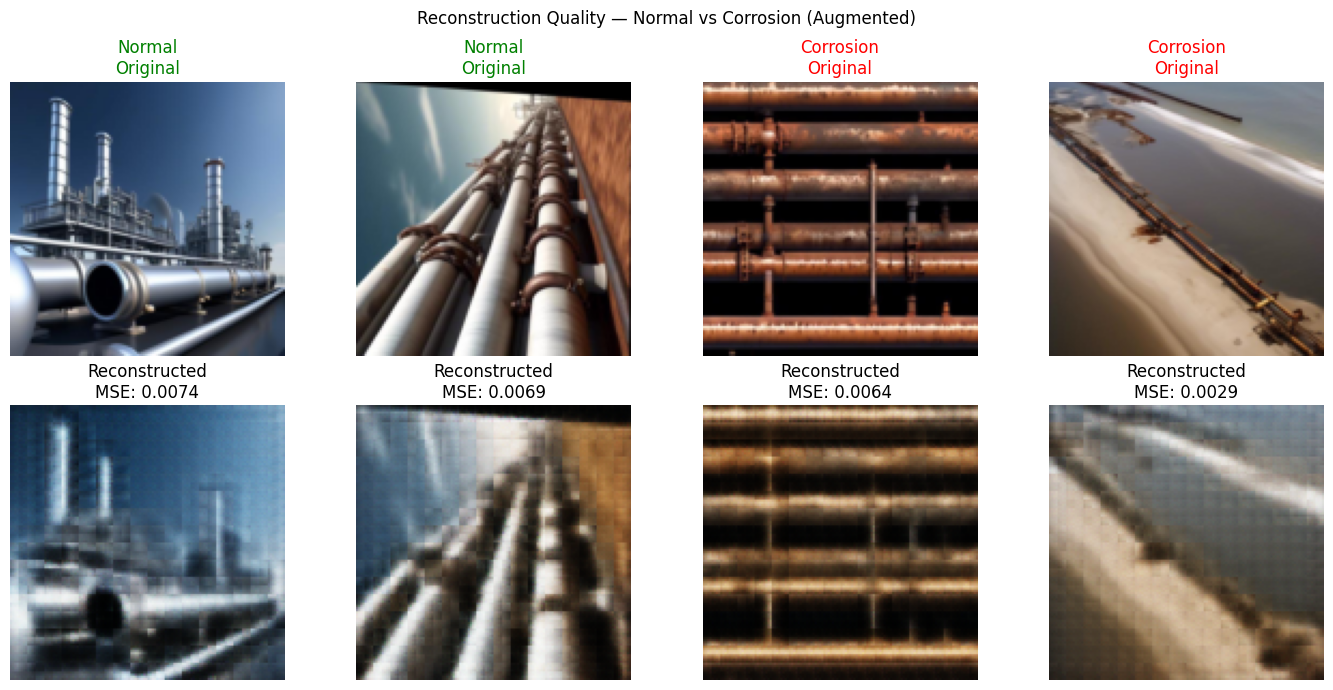

In [8]:
model.eval()
all_images  = []
all_outputs = []
all_lbls    = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images)
        all_images.append(images.cpu())
        all_outputs.append(outputs.cpu())
        all_lbls.extend(labels.numpy())

all_images  = torch.cat(all_images)
all_outputs = torch.cat(all_outputs)
all_lbls    = np.array(all_lbls)

normal_idx       = np.where(all_lbls == test_dataset.class_to_idx['no_corrosion'])[0][:2]
corrosion_idx_arr = np.where(all_lbls == corrosion_cls)[0][:2]
show_idx         = np.concatenate([normal_idx, corrosion_idx_arr])

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
col_titles = ['Normal', 'Normal', 'Corrosion', 'Corrosion']

for col, idx in enumerate(show_idx):
    orig  = all_images[idx].permute(1, 2, 0).numpy()
    recon = all_outputs[idx].permute(1, 2, 0).numpy()
    err   = np.mean((orig - recon) ** 2)
    axes[0, col].imshow(np.clip(orig, 0, 1))
    axes[0, col].set_title(f'{col_titles[col]}\nOriginal',
                            color='green' if 'Normal' in col_titles[col] else 'red')
    axes[0, col].axis('off')
    axes[1, col].imshow(np.clip(recon, 0, 1))
    axes[1, col].set_title(f'Reconstructed\nMSE: {err:.4f}')
    axes[1, col].axis('off')

plt.suptitle('Reconstruction Quality — Normal vs Corrosion (Augmented)')
plt.tight_layout()
plt.savefig(r'C:\Users\Administrator\Documents\kf7029-w25039720\results\figures\aug_reconstruction_comparison.png', dpi=150)
plt.show()

## 9. Extract Encoder Features for Classical Baselines
Classical methods applied to flattened encoder feature representations. This ensures fair comparison — classical methods operate on the same learned feature space rather than raw pixels.

In [9]:
def extract_features(loader, model, device):
    features_list = []
    labels_list   = []
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            feats  = model.encode(images)
            feats  = feats.view(feats.size(0), -1).cpu().numpy()
            features_list.append(feats)
            labels_list.extend(labels.numpy())
    return np.vstack(features_list), np.array(labels_list)

train_feats, train_feat_labels = extract_features(train_loader, model, device)
test_feats,  test_feat_labels  = extract_features(test_loader,  model, device)
valid_feats, valid_feat_labels = extract_features(valid_loader, model, device)

# Normal only for training
normal_mask        = (train_feat_labels == train_dataset.class_to_idx['no_corrosion'])
train_feats_normal = train_feats[normal_mask]

# Remap test and valid labels
test_feat_labels_remapped  = (test_feat_labels  == corrosion_cls).astype(int)
valid_feat_labels_remapped = (valid_feat_labels == corrosion_cls).astype(int)

print('Train normal feature shape:', train_feats_normal.shape)
print('Test feature shape:        ', test_feats.shape)
print(f'Test — Normal: {(test_feat_labels_remapped==0).sum()} | Anomalous: {(test_feat_labels_remapped==1).sum()}')

Train normal feature shape: (434, 32768)
Test feature shape:         (108, 32768)
Test — Normal: 54 | Anomalous: 54


## 10. Classical Baseline — Isolation Forest on Encoder Features
**Reference:** Liu, Ting & Zhou (2008). Isolation Forest. IEEE ICDM.

In [10]:
# contamination=0.5 because test set is balanced 50:50
iso = IsolationForest(n_estimators=100, contamination=0.5, random_state=42)
iso.fit(train_feats_normal)

iso_scores = -iso.score_samples(test_feats)
iso_preds  = (iso_scores > np.percentile(iso_scores, 50)).astype(int)
evaluate_model('Isolation Forest (Encoder)', iso_scores, iso_preds, test_feat_labels_remapped)


=== Isolation Forest (Encoder) ===
  ROC-AUC: 0.619
  PR-AUC: 0.6598
  F1: 0.5926
  Precision: 0.5926
  Recall: 0.5926


## 11. Classical Baseline — One-Class SVM on Encoder Features
**Reference:** Schölkopf et al. (2001). Neural Computation.

In [11]:
ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.5)
ocsvm.fit(train_feats_normal)

ocsvm_scores = -ocsvm.score_samples(test_feats)
ocsvm_preds  = (ocsvm_scores > np.percentile(ocsvm_scores, 50)).astype(int)
evaluate_model('One-Class SVM (Encoder)', ocsvm_scores, ocsvm_preds, test_feat_labels_remapped)


=== One-Class SVM (Encoder) ===
  ROC-AUC: 0.5398
  PR-AUC: 0.5337
  F1: 0.5185
  Precision: 0.5185
  Recall: 0.5185


## 12. Results Summary

=== COMPLETE RESULTS — K-PIPELINES AUGMENTED IMAGE MODALITY ===
                            ROC-AUC  PR-AUC      F1  Precision  Recall
Conv Autoencoder             0.4321  0.4486  0.4630     0.4630  0.4630
Isolation Forest (Encoder)   0.6190  0.6598  0.5926     0.5926  0.5926
One-Class SVM (Encoder)      0.5398  0.5337  0.5185     0.5185  0.5185


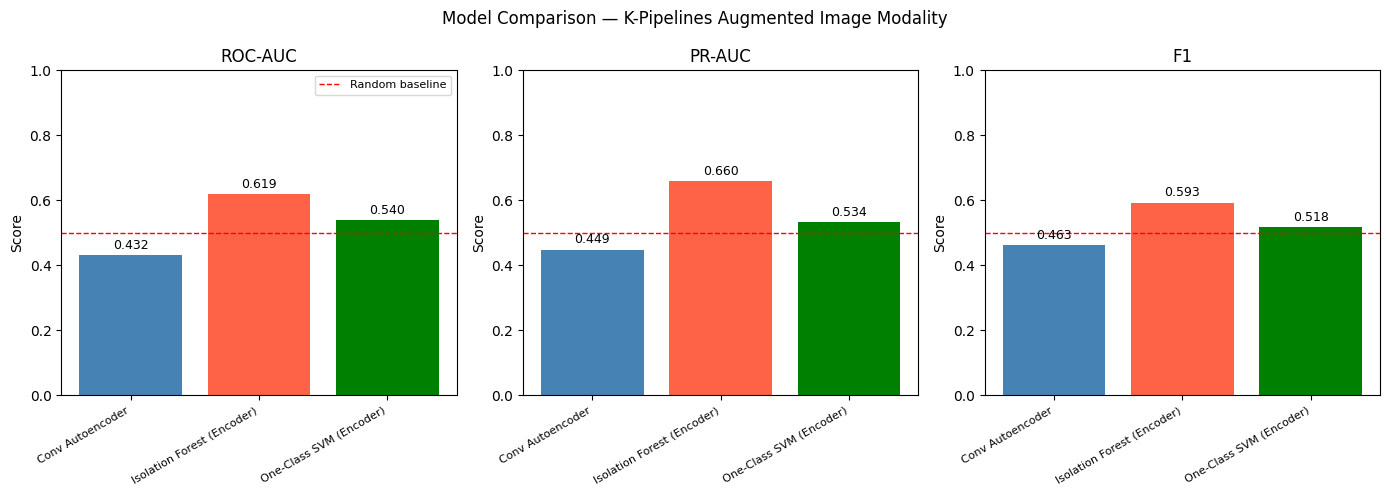

In [12]:
results_df = pd.DataFrame(results).T
print('=== COMPLETE RESULTS — K-PIPELINES AUGMENTED IMAGE MODALITY ===')
print(results_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['ROC-AUC', 'PR-AUC', 'F1']
colors  = ['steelblue', 'tomato', 'green']

for ax, metric in zip(axes, metrics):
    bars = ax.bar(results_df.index, results_df[metric], color=colors)
    ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Random baseline')
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.set_xticklabels(results_df.index, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Score')
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

axes[0].legend(fontsize=8)
plt.suptitle('Model Comparison — K-Pipelines Augmented Image Modality', fontsize=12)
plt.tight_layout()
plt.savefig(r'C:\Users\Administrator\Documents\kf7029-w25039720\results\figures\aug_model_comparison.png', dpi=150)
plt.show()

## Results Interpretation
Results on the K-Pipelines Augmented dataset with 108 test images provide more reliable estimates than the Standard split (60 images). The balanced test set (54 normal, 54 corrosion) means PR-AUC and ROC-AUC are directly comparable.

Classical baselines applied to encoder features are compared against the Conv Autoencoder reconstruction error to determine whether learned representations carry additional discriminative information beyond reconstruction quality alone. Deep SVDD results will be added in Notebook 03.

## 13. Save Results and Models

In [13]:
BASE = r'C:\Users\Administrator\Documents\kf7029-w25039720'

results_df.to_csv(fr'{BASE}\results\image_aug_results.csv')

with open(fr'{BASE}\results\image_aug_results.pkl', 'wb') as f:
    pickle.dump(results, f)

torch.save(model.state_dict(),
    fr'{BASE}\models\saved_models\conv_autoencoder_aug.pth')

np.save(fr'{BASE}\datasets\k-pipelines\aug_train_feats_normal.npy', train_feats_normal)
np.save(fr'{BASE}\datasets\k-pipelines\aug_test_feats.npy', test_feats)
np.save(fr'{BASE}\datasets\k-pipelines\aug_test_labels.npy', test_feat_labels_remapped)
np.save(fr'{BASE}\datasets\k-pipelines\aug_valid_feats.npy', valid_feats)
np.save(fr'{BASE}\datasets\k-pipelines\aug_valid_labels.npy', valid_feat_labels_remapped)
np.save(fr'{BASE}\datasets\k-pipelines\aug_ae_test_scores.npy', ae_errors)
np.save(fr'{BASE}\datasets\k-pipelines\aug_ae_test_labels.npy', true_labels_remapped)

print('All results and models saved successfully.')
print('\nSaved files:')
print('  results/image_aug_results.csv')
print('  results/image_aug_results.pkl')
print('  models/saved_models/conv_autoencoder_aug.pth')

All results and models saved successfully.

Saved files:
  results/image_aug_results.csv
  results/image_aug_results.pkl
  models/saved_models/conv_autoencoder_aug.pth
